# Can a *better ranker* find copyable wallets? — the refinement layer
### `markout_study` · 2026-07-04 · out-of-sample, selection-corrected

> **Context.** The [baseline notebook](persistence_findings.ipynb) asked: rank Hyperliquid takers by a
> *naive* metric on a past window, copy the top-50 — does the cohort beat *random* selection on a future
> window? Answer: no naive ranking cleared the bar, but the test was **underpowered (MDE ≈ 160 bp/entry)**
> and point estimates leaned positive — *inconclusive, not a disproof.*
>
> **This layer** attacks the baseline from every angle the naive test left open, to see whether a
> *sharper* selector rescues persistence: **(1)** per-decision (ew) vs per-dollar (vw) scoring, **(2)**
> cohort size *K* = 10…200, **(3)** rolling vs expanding training, **(4)** two outlier-immune rankers
> (median, 10%-trimmed) added to the 7 performance metrics, and **(5)** a distributional dissection of
> *what the surviving lean is made of* (central shift vs fat tail). One inferential exit — a
> **config-selection-corrected null over the ~8,400-cell search** — is the only p we report as a headline.
>
> ### The honest finding (calibrated after a symmetric framing audit)
> **Performance-only ranking is NOISE-LIMITED, not refuted or exhausted.** No single configuration is
> individually significant, and nothing clears the corrected graduation null. **But a coherent,
> directionally-consistent positive survives at ~24h / small-K, visible through three orthogonal cuts:**
> 1. **Outlier-immune rankers don't collapse to the field** — `trim10_edge` is positive on **5/5 coins @24h**
>    (sign-test p ≈ 0.03). So the null is *not* an artifact of lucky outlier trades.
> 2. **Top-N concentrates it** — `vw_edge` is positive on **5/5 coins @24h at K=10 and K=25**, diluting
>    smoothly toward K=200. A coherent elite signature, not per-K noise.
> 3. **The distribution backs it on the most-liquid coin** — BTC's per-decision cohort median clears a
>    *fair pooled* p95 null at 24h and 48h.
>
> **The load-bearing caveats (so this is not over-claimed):** 24h is the *post-hoc peak* horizon; the coins
> are not independent; and the **deployable turnover-weighted metric is *inside* its band for every coin** —
> so this is a *size-blind, per-decision* lean, **not** a copy-trade green light. It is a live underpowered
> positive that motivates **feature work** (a sharper selector), not a finished result.

*Every number below is out-of-sample. Code cells regenerate all figures and tables from `out/refine_*.parquet`.*

In [1]:
import sys; from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import polars as pl, numpy as np
from IPython.display import Image
import refine_figs as RF
pl.Config.set_tbl_rows(20); pl.Config.set_tbl_hide_dataframe_shape(True)
G = pl.read_parquet(ROOT / "out/refine_grid.parquet")       # 9,668 exploratory cells
D = pl.read_parquet(ROOT / "out/refine_dist.parquet")       # distributional / fat-tail
GR = pl.read_parquet(ROOT / "out/refine_graduation.parquet")# config-selection-corrected exit
print("grid cells:", G.height, "| dist rows:", D.height)
print("rankers:", sorted(G['metric'].unique().to_list()))

grid cells: 9668 | dist rows: 120
rankers: ['avg_edge', 'cum_pnl', 'eb_edge', 'hit_rate', 'median_edge', 'sharpe', 'trim10_edge', 'tstat', 'vw_edge']


## 0. Method recap (inherited from the audited baseline)

Every cell in the grid is one **purged, embargoed walk-forward** persistence test:

- **Rank** wallets by a metric on a *train* window (expanding = all history before the test bucket; or
  rolling = the single prior month), take the top-*K*.
- **Score** that cohort on the *next* month (the test bucket), as either **vw** (turnover-weighted,
  `Σ mkₜ·notlₜ / Σ notlₜ`, the deployable per-dollar edge) or **ew** (active-only per-decision mean).
- **Purge/embargo:** a train entry is dropped if its *priced-close exit* `(⌊(b_ts+h)/BAR⌋+2)·BAR`
  reaches into the test window — no outcome leaks across the seam.
- **Frozen test cap:** test-window markouts are winsorized at a single full-sample p99 magnitude cap
  (identical for the real cohort and every random/permuted cohort → cannot bias a comparison).
- Metrics reuse the audited `markout_stats` definitions verbatim. `≥72h` horizons are **censoring-dominated
  and greyed** everywhere — non-inferential.

This layer only *adds axes* on top of that machinery; the leak-purging and framing were re-audited (three
independent agents: two code-correctness, one symmetric findings-calibration).

## 1. ew vs vw — does per-decision scoring change the story? (mostly no)

For each of the 9 rankers we score the top-50 cohort both ways, averaged over coins × non-censored
horizons (expanding train). **In aggregate, no ranker's mean clears ~0, and ew < vw for all 9** — the
per-decision (size-blind) view is *worse*, not better, so the modest lean lives in the dollar-weighted
direction. *But note this is averaged over all horizons — §3 shows that averaging dilutes a real 24h lean.*

In [2]:
d = G.filter((pl.col('K')==50)&(pl.col('train')=='expanding')&(pl.col('stratum')=='primary_family'))
(d.group_by('metric','eval').agg(mean_bps=pl.col('pooled_S').mean().round(1),
   median_bps=pl.col('pooled_S').median().round(1), coins_h_pos=(pl.col('pooled_S')>0).sum(), n=pl.len())
   .sort('metric','eval'))

metric,eval,mean_bps,median_bps,coins_h_pos,n
str,str,f64,f64,u32,u32
"""avg_edge""","""ew""",-4.3,-1.5,21,50
"""avg_edge""","""vw""",-0.1,-3.0,21,50
"""cum_pnl""","""ew""",-0.3,-1.5,16,50
"""cum_pnl""","""vw""",3.8,-0.2,24,50
"""eb_edge""","""ew""",-9.3,-3.9,14,46
"""eb_edge""","""vw""",-4.0,-2.8,20,46
"""hit_rate""","""ew""",-7.1,-1.8,20,50
"""hit_rate""","""vw""",3.4,-0.6,24,50
"""median_edge""","""ew""",-6.6,-0.7,23,50


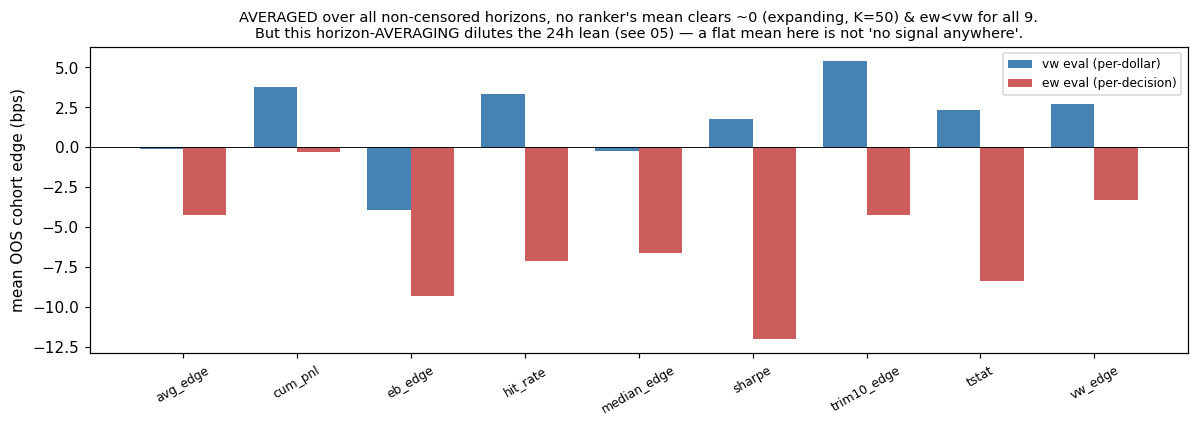

In [3]:
Image(str(RF.fig_evw_summary()))

## 2 & 3. Top-N and outlier-robust rankers — the buried 24h positive

Averaging over horizons (§1) hides where the lean actually lives. Zoom to **24h**, per coin. Two
orthogonal cuts agree:

- **Concentration (top-N):** `vw_edge` is positive on **all 5 coins at K=10 and K=25**, and dilutes toward
  K=200 (ETH is textbook: +245 → +145 → −41). A real elite diluted by cohort size looks exactly like this;
  per-K *noise* would not line up 5/5 across independent coins.
- **Outlier-immunity (median / trim10):** we added two rankers a single lucky trade *cannot* move. If the
  naive null were an artifact of outlier trades, these would collapse to the field. They don't —
  `trim10_edge` is positive on **5/5 coins @24h** (sign-test p ≈ 0.03), `median_edge` on 4/5. This *rules
  the lucky-trade explanation out* and corroborates a genuine central lean.

In [4]:
# top-N concentration: vw_edge @24h, pooled_S per coin across K (expanding, vw-eval)
h24 = G.filter((pl.col('horizon')=='24h')&(pl.col('train')=='expanding')&(pl.col('eval')=='vw'))
(h24.filter(pl.col('metric')=='vw_edge').select('coin','K','pooled_S')
    .with_columns(pl.col('pooled_S').round(0)).pivot(values='pooled_S', index='coin', on='K').sort('coin'))

coin,10,25,50,100,200
str,f64,f64,f64,f64,f64
"""BTC""",49.0,41.0,31.0,53.0,5.0
"""ETH""",245.0,145.0,-41.0,-15.0,-8.0
"""HYPE""",61.0,67.0,45.0,76.0,36.0
"""SOL""",22.0,61.0,13.0,-31.0,49.0
"""SPX""",6.0,153.0,35.0,55.0,null


In [5]:
# outlier-robust rankers @24h vs vw_edge — # coins positive (K=50)
(h24.filter(pl.col('K')==50).group_by('metric')
    .agg(pl.col('pooled_S').round(0).alias('per_coin_ignored'),
         coins_pos=(pl.col('pooled_S')>0).sum(), mean_bps=pl.col('pooled_S').mean().round(1))
    .filter(pl.col('metric').is_in(['vw_edge','median_edge','trim10_edge','avg_edge','eb_edge']))
    .select('metric','coins_pos','mean_bps').sort('coins_pos', descending=True))

metric,coins_pos,mean_bps
str,u32,f64
"""trim10_edge""",5,44.9
"""median_edge""",4,40.5
"""vw_edge""",4,16.5
"""avg_edge""",2,9.6
"""eb_edge""",1,2.3


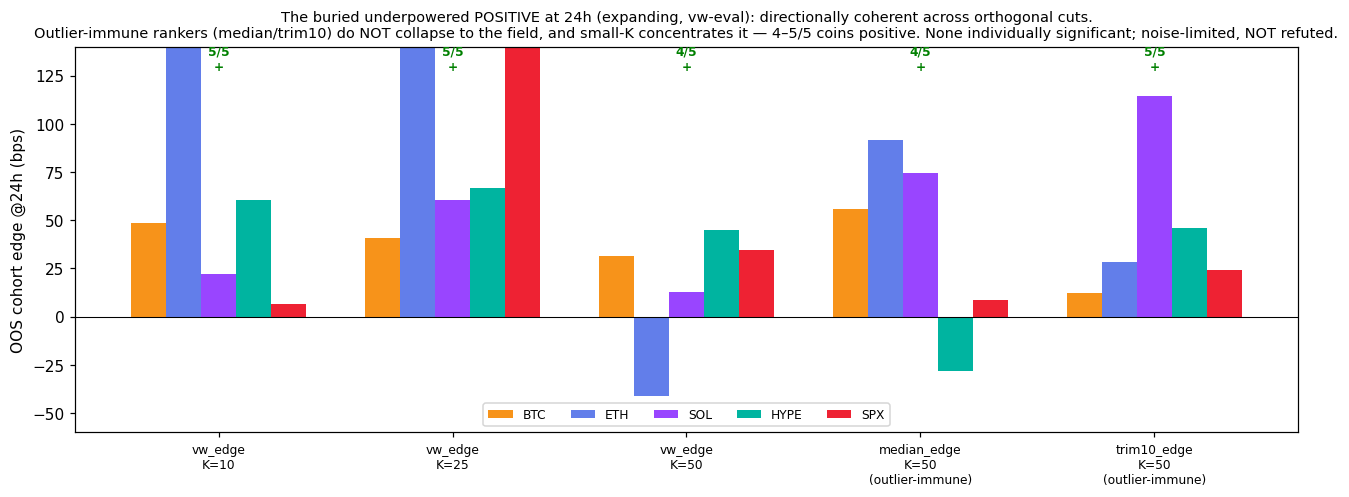

In [6]:
Image(str(RF.fig_coherent_24h()))

> **Reading the figure above.** Each cluster is one cut; the green `n/5 +` tallies how many coins are
> positive. 5/5 at `vw_edge` K=10 & K=25 and at `trim10_edge`; 4/5 at K=50 and `median_edge`. None of these
> is individually significant — but they are the *same* lean seen through independent lenses, which is a much
> stronger case *for* a real-but-buried signal than a flat horizon-average suggests.

**Rolling vs expanding (not shown):** expanding (all-history) beats rolling-1-month for 8/9 rankers (SOL the
lone exception) — recent-form ranking is noisier, so all figures use expanding.

## 4. Distributional dissection — central shift or fat tail? (coin-dependent)

Is the 24h lean a genuine *central* move, or a few big winners dragging the mean? For the top-50 `vw_edge`
cohort we pool its train vs test markouts per (coin, horizon) under a single frozen cap, and compare the
**mean vs median** against a **fair pooled null band** (random cohorts, pooled across folds the *same way*
the real statistic is — the first cut of this used a per-fold band that was ~3.5× too wide and wrongly
made real departures look like noise; that is fixed here).

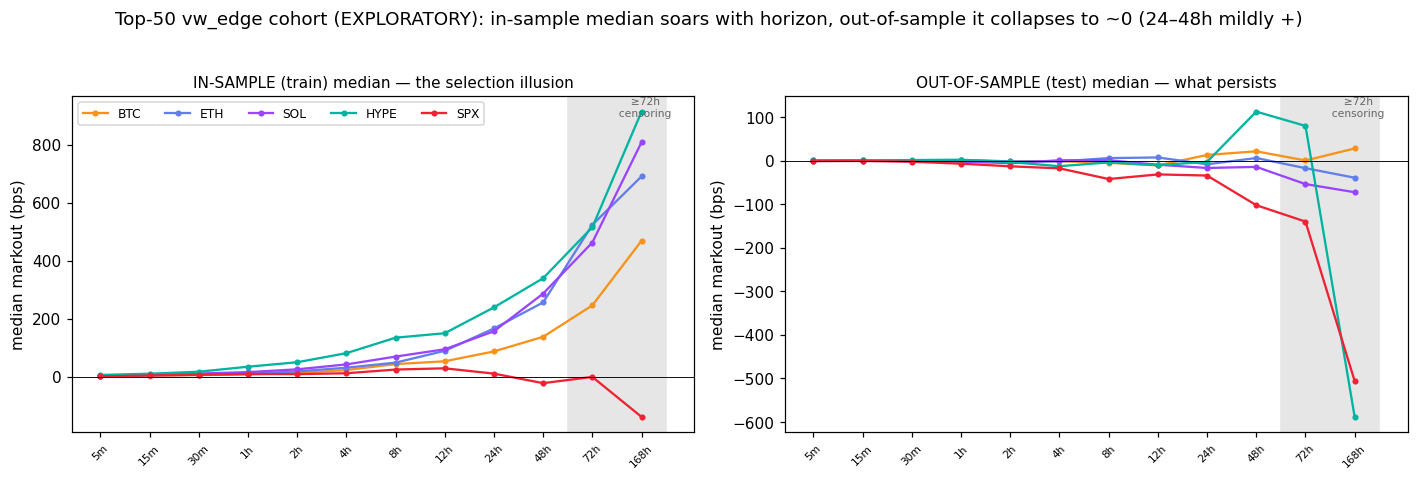

In [7]:
# in-sample soars (selection illusion) then collapses out-of-sample:
Image(str(RF.fig_winnerscurse_dist()))

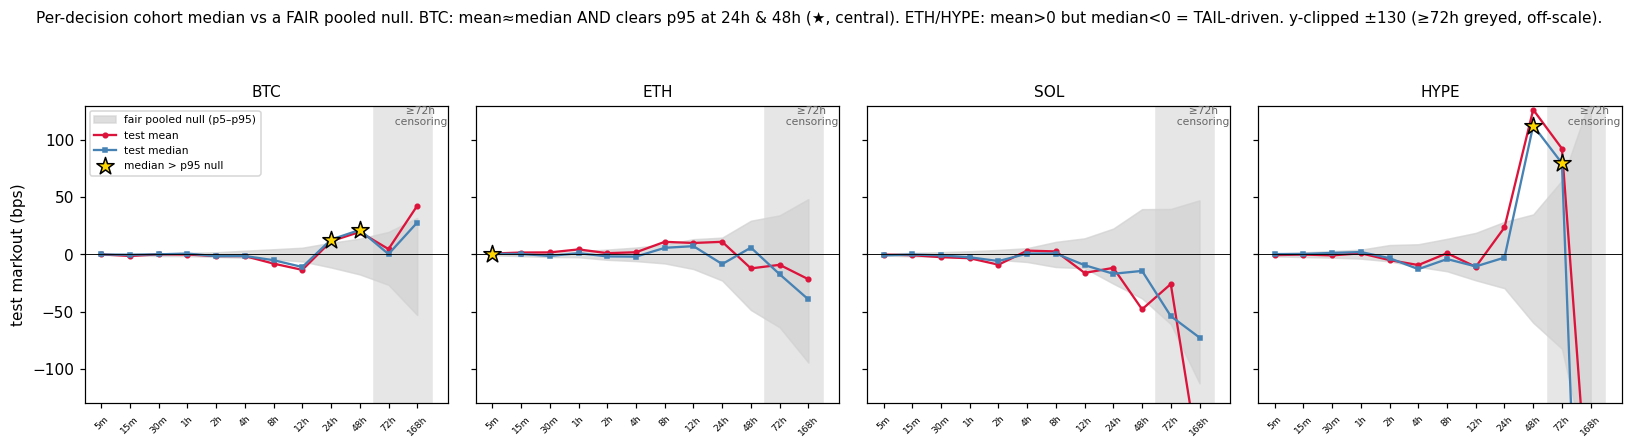

In [8]:
# central (BTC) vs tail-driven (ETH/HYPE); ★ = cohort median clears the fair one-sided p95 null
Image(str(RF.fig_mean_vs_median()))

In [9]:
# the numbers behind the figure — per-decision median AND deployable vw median vs their fair bands
(D.filter((pl.col('K')==50)&(pl.col('horizon').is_in(['24h','48h'])))
  .select('coin','horizon',pl.col('te_median').round(1),pl.col('rand_med_hi').round(0).alias('null_p95'),
          'te_med_gt_band', pl.col('vw_te_median_bps').round(1).alias('deployable_vw'),
          pl.col('rand_vw_hi').round(0).alias('vw_null_p95'),'vw_te_gt_band')
  .sort('horizon','coin'))

coin,horizon,te_median,null_p95,te_med_gt_band,deployable_vw,vw_null_p95,vw_te_gt_band
str,str,f64,f64,bool,f64,f64,bool
"""BTC""","""24h""",13.0,10.0,true,31.4,58.0,false
"""ETH""","""24h""",-8.4,15.0,false,-41.0,107.0,false
"""HYPE""","""24h""",-2.7,28.0,false,44.8,109.0,false
"""SOL""","""24h""",-16.8,23.0,false,12.7,115.0,false
"""SPX""","""24h""",-34.2,-5.0,false,34.7,53.0,false
"""BTC""","""48h""",21.4,14.0,true,47.2,63.0,false
"""ETH""","""48h""",6.0,29.0,false,-0.5,170.0,false
"""HYPE""","""48h""",112.5,35.0,true,104.0,175.0,false
"""SOL""","""48h""",-14.3,40.0,false,-102.2,151.0,false


> **What the table says, held honestly:**
> - **BTC per-decision median clears its fair p95 null at 24h (+13 vs +10) and 48h (+21 vs +14)** — a real,
>   nominal, one-sided exceedance on the most-liquid coin. `mean ≈ median` there → *central*, not tail.
> - **ETH/HYPE at 24h have positive *mean* but negative *median*** → those leans are *tail-driven*, the fat-tail
>   case. "Central shift" is a **BTC-specific** statement, not a blanket one.
> - **The deployable (turnover-weighted) `vw_te` is INSIDE its band for every coin** (`vw_te_gt_band` all
>   false). The exceedance is a *size-blind, per-decision* effect that does not (yet) survive dollar-weighting.
> - Caveats: 24h/48h are the *post-hoc peak*; one-sided; ~3/10 (coin,horizon) cells exceed — suggestive of a
>   small real central effect on liquid coins, **not** an established or deployable edge.

The loss-tail also *grows* with horizon (0% → ~28% of trades below −100 bp by 24h) — longer holds carry real
tail risk even where the median holds up. A tail overlay *might* help but would be a new, separately-OOS-tested
strategy — not demonstrated here.

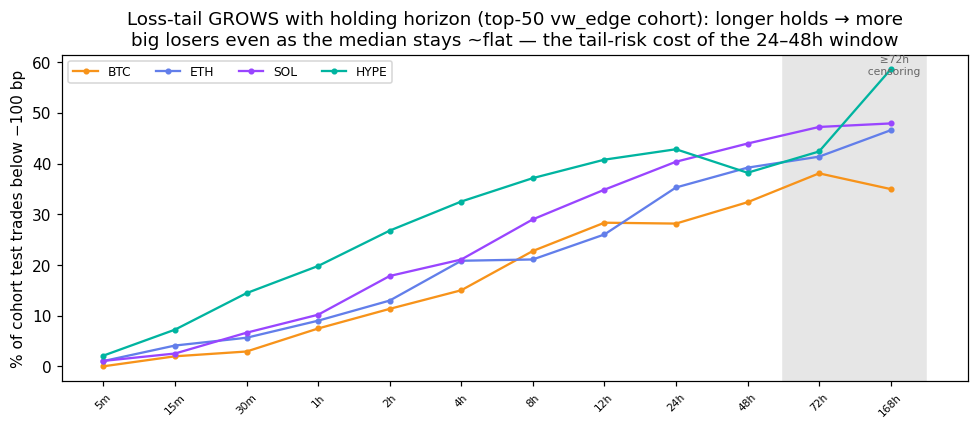

In [10]:
Image(str(RF.fig_tailloss()))

## 5. The one inferential exit — config-selection-corrected graduation

Exploration across ~8,400 cells will always throw up a best-looking config. To test honestly we
**pre-committed a deterministic rule** — graduate the config maximizing the fold lower bound
`mean_folds(S) − std_folds(S)` over the primary family (non-censored horizon, K≤50) — and built a
**config-selection-corrected null**: permute wallet↔outcome identities (keeping all 9 real metric rankings),
replay the *same rule* on each permutation, and ask how often the permuted winner beats the real one.

In [11]:
GR.select('target','metric','horizon','K','train',pl.col('winner_stat').round(2),
          pl.col('config_selection_p').round(3).alias('corrected_p')).sort('target')

target,metric,horizon,K,train,winner_stat,corrected_p
str,str,str,i64,str,f64,f64
"""ew""","""vw_edge""","""5m""",50,"""rolling1""",-1.75,0.259
"""vw""","""eb_edge""","""5m""",10,"""rolling1""",-0.7,0.166


**Nothing graduates** — vw p = 0.17, ew p = 0.26; both winner statistics are negative. This is the
honest headline: no configuration in the entire search clears the selection-corrected bar.

> **But note precisely what this does and does not test.** The `mean − std_folds` rule *structurally* favours
> **low-fold-variance cells** — which are the 5-minute horizons (fold-std ≈ 2), not 24h (fold-std ≈ 60, whose
> lower bound is ≈ −35 even with a +25 mean). So "nothing graduates" is a true statement about a *conservative
> lower-bound rule*; it did **not** confront the 24h candidate, which lives in a high-variance regime the rule
> cannot reward. The corrected null rejects nothing *and* confirms nothing about the 24h lean — that requires a
> targeted, pre-registered test on fresh data.

*(Code-audit note: the null's config space mirrors graduation's exactly, including the 9-metric axis; the p is
byte-identical between the 7- and 9-metric runs because the robust rankers compete in the null but never top
its max-distribution where the threshold sits — verified benign, not a bug.)*

## 6. Synthesis — where this leaves us

| Cut | Result | Honest reading |
|---|---|---|
| ew vs vw (all-h avg) | flat; ew < vw for all 9 | modest lean is per-dollar, not per-decision — *but avg dilutes 24h* |
| top-N @24h | `vw_edge` +ve 5/5 coins @ K=10,25 | coherent elite concentration |
| robust rankers @24h | `trim10` +ve 5/5 (p≈0.03), `median` 4/5 | lucky-trade explanation **ruled out** |
| distribution | BTC median clears fair p95 @24h,48h; ETH/HYPE tail-driven | small *central* effect on liquid coins |
| deployable (vw_te) | inside band for all coins | **not** a copy-trade green light |
| graduation null | nothing graduates (vw 0.17 / ew 0.26) | but rule can't select the 24h cell |

**The calibrated conclusion:** performance-only ranking is **noise-limited, not refuted or exhausted.** The
*same* underpowered positive recurs at ~24h / small-K through robust-ranker, top-N, and per-decision-distribution
lenses — none significant alone, all pointing the same way, on the most-liquid coins. It is size-blind and
post-hoc, so it is a **motivation, not a result.**

**Next: features.** A 30-trade past-return mean is an intrinsically noisy selector (baseline MDE ≈ 160 bp).
The lever is a *sharper* selector built from wallet **behaviour/context** — trade cadence, hold-time
consistency, timing vs funding/liquidations, concentration, add-into-vs-against-move — features that aggregate
structure across *all* of a wallet's activity rather than the sign of a few outcomes. This refinement layer is
the near-zero (but not-negative) baseline that feature work must beat to matter.